## 🛒 Retail Demand Analysis Using Python and SQL

##

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

In [4]:
df = pd.read_csv("Retail_Transaction_Dataset.csv")
df.head()

,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount
0,109318,C,7,80.079844,12/26/2023 12:32,Cash,"176 Andrew Cliffs\nBaileyfort, HI 93354",Books,18.677100,455.862764
1,993229,C,4,75.195229,8/5/2023 0:00,Cash,"11635 William Well Suite 809\nEast Kara, MT 19483",Home Decor,14.121365,258.306546
2,579675,A,8,31.528816,3/11/2024 18:51,Cash,"910 Mendez Ville Suite 909\nPort Lauraland, MO...",Books,15.943701,212.015651
3,799826,D,5,98.880218,10/27/2023 22:00,PayPal,"87522 Sharon Corners Suite 500\nLake Tammy, MO...",Books,6.686337,461.343769
4,121413,A,7,93.188512,12/22/2023 11:38,Cash,"0070 Michelle Island Suite 143\nHoland, VA 80142",Electronics,4.030096,626.030484


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   CustomerID          100000 non-null  int64  
 1   ProductID           100000 non-null  object 
 2   Quantity            100000 non-null  int64  
 3   Price               100000 non-null  float64
 4   TransactionDate     100000 non-null  object 
 5   PaymentMethod       100000 non-null  object 
 6   StoreLocation       100000 non-null  object 
 7   ProductCategory     100000 non-null  object 
 8   DiscountApplied(%)  100000 non-null  float64
 9   TotalAmount         100000 non-null  float64
dtypes: float64(3), int64(2), object(5)
memory usage: 5.7+ MB


In [6]:
df.describe()

,CustomerID,Quantity,Price,DiscountApplied(%),TotalAmount
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,500463.982180,5.009290,55.067344,10.020155,248.334955
std,288460.917524,2.579808,25.971567,5.779534,184.554792
min,14.000000,1.000000,10.000430,0.000046,8.274825
25%,250693.750000,3.000000,32.549474,5.001013,95.163418
50%,499679.000000,5.000000,55.116789,10.030353,200.368393
75%,751104.750000,7.000000,77.456763,15.018367,362.009980
max,999997.000000,9.000000,99.999284,19.999585,896.141242


In [7]:
df.isnull().sum()

CustomerID            0
ProductID             0
Quantity              0
Price                 0
TransactionDate       0
PaymentMethod         0
StoreLocation         0
ProductCategory       0
DiscountApplied(%)    0
TotalAmount           0
dtype: int64

In [8]:
df = df.drop(columns=["StoreLocation"], errors="ignore")

In [9]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"], errors="coerce")

In [10]:
df = df.dropna()

In [11]:
df["Month"] = df["TransactionDate"].dt.month

In [12]:
df["DayOfWeek"] = df["TransactionDate"].dt.day_name()

In [13]:
df.groupby("ProductID")["Quantity"].sum().nlargest(10)

ProductID
C    125978
D    125786
B    125070
A    124095
Name: Quantity, dtype: int64

In [14]:
df["Revenue"] = df["Quantity"] * df["Price"] * (1 - df["DiscountApplied(%)"] / 100)

In [18]:
df.head()

,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,ProductCategory,DiscountApplied(%),TotalAmount,Month,DayOfWeek,Revenue
0,109318,C,7,80.079844,2023-12-26 12:32:00,Cash,Books,18.677100,455.862764,12,Tuesday,455.862764
1,993229,C,4,75.195229,2023-08-05 00:00:00,Cash,Home Decor,14.121365,258.306546,8,Saturday,258.306546
2,579675,A,8,31.528816,2024-03-11 18:51:00,Cash,Books,15.943701,212.015651,3,Monday,212.015651
3,799826,D,5,98.880218,2023-10-27 22:00:00,PayPal,Books,6.686337,461.343769,10,Friday,461.343769
4,121413,A,7,93.188512,2023-12-22 11:38:00,Cash,Electronics,4.030096,626.030484,12,Friday,626.030484


In [19]:
print("Total Revenue:", df["Revenue"].sum())

Total Revenue: 24833495.506372266


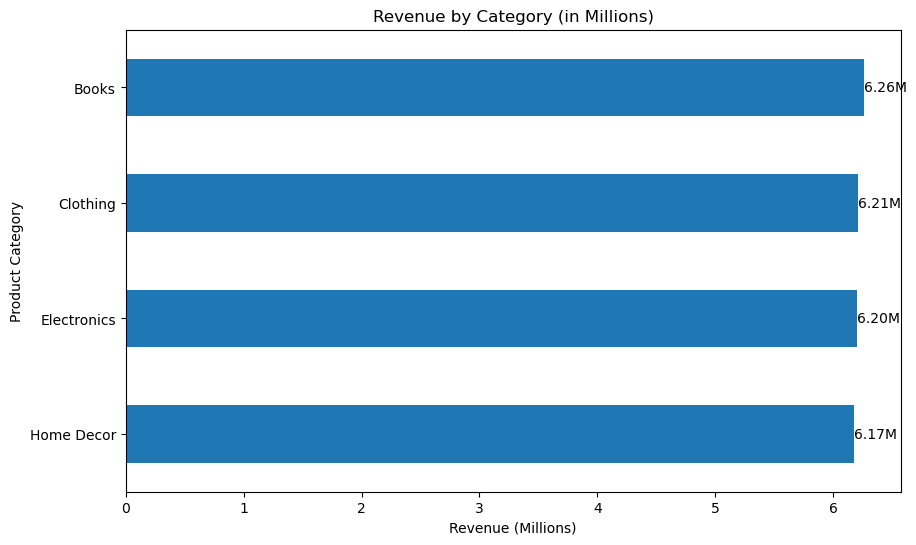

In [20]:
plt.figure(figsize=(10,6))

data = df.groupby("ProductCategory")["Revenue"].sum().sort_values() / 1_000_000

ax = data.plot(kind="barh")

for i, v in enumerate(data):
    ax.text(v, i, f"{v:.2f}M", va='center')

plt.title("Revenue by Category (in Millions)")
plt.xlabel("Revenue (Millions)")
plt.ylabel("Product Category")

plt.show()

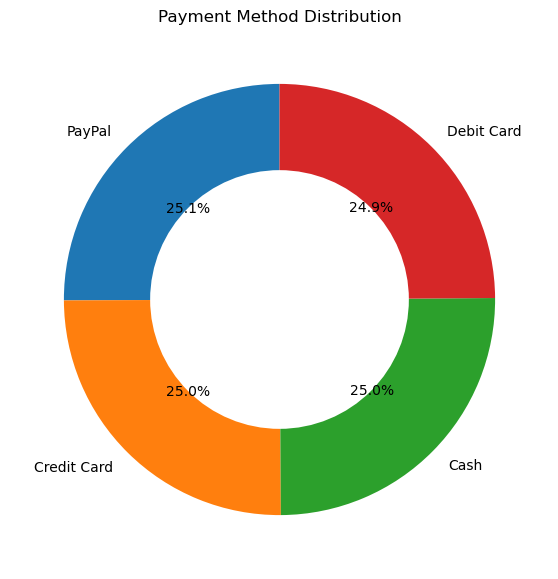

In [21]:


data = df["PaymentMethod"].value_counts()

plt.figure(figsize=(7,7))

wedges, texts, autotexts = plt.pie(
    data,
    labels=data.index,
    autopct='%1.1f%%',
    startangle=90
)

# donut hole
centre_circle = plt.Circle((0,0),0.60,fc='white')
plt.gca().add_artist(centre_circle)

plt.title("Payment Method Distribution")
plt.show()

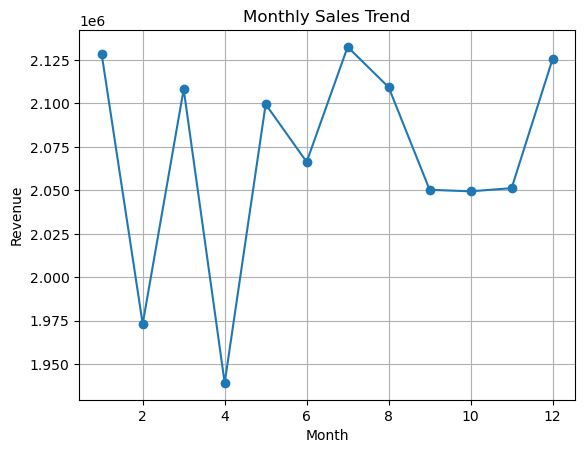

In [22]:
data = df.groupby("Month")["Revenue"].sum().sort_index()

data.plot(kind="line", marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid()
plt.show()

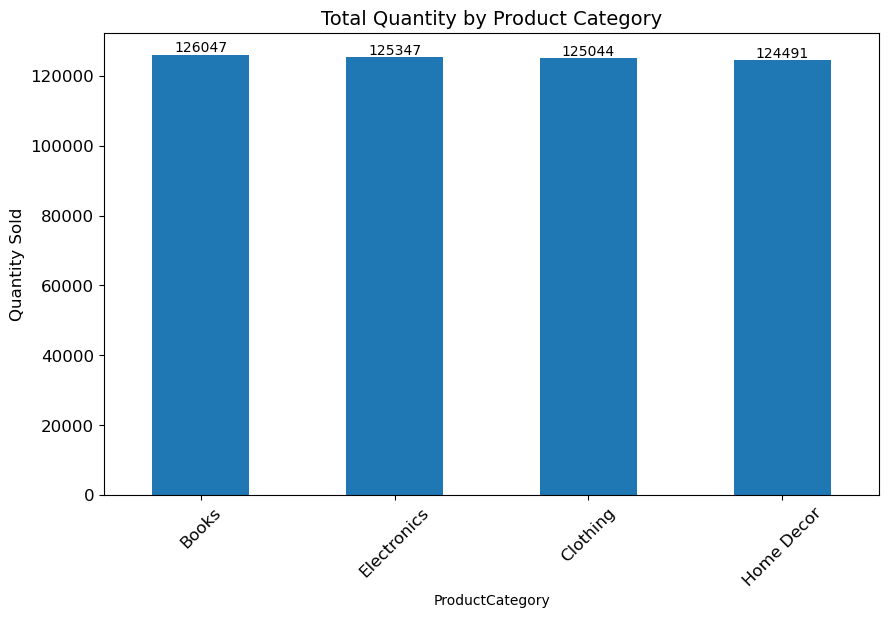

In [23]:
plt.figure(figsize=(10,6))  # increase graph size

data = df.groupby("ProductCategory")["Quantity"].sum().sort_values(ascending=False)

ax = data.plot(kind="bar")

# increase label size
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# add data labels on top
for i, v in enumerate(data):
    ax.text(i, v, str(int(v)), ha='center', va='bottom', fontsize=10)

plt.title("Total Quantity by Product Category", fontsize=14)
plt.ylabel("Quantity Sold", fontsize=12)
plt.show()

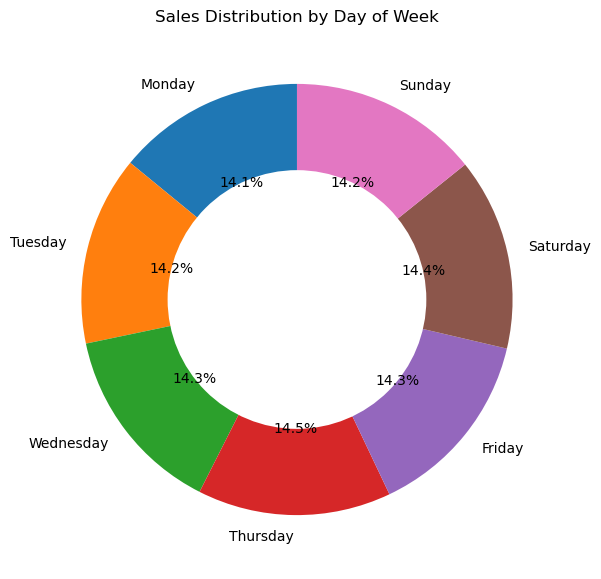

In [24]:
import matplotlib.pyplot as plt

# correct order
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

data = df.groupby("DayOfWeek")["Revenue"].sum().reindex(order)

plt.figure(figsize=(7,7))

# create donut
wedges, texts, autotexts = plt.pie(
    data,
    labels=data.index,
    autopct='%1.1f%%',   # percentage labels
    startangle=90
)

# draw center circle (donut hole)
centre_circle = plt.Circle((0,0),0.60,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sales Distribution by Day of Week")
plt.show()

In [32]:
conn = sqlite3.connect(":memory:")
df.to_sql("sales", conn, if_exists="replace", index=False)

100000

In [33]:
df.shape

(100000, 12)

In [36]:
query = """
SELECT ProductCategory, SUM(Revenue) AS TotalRevenue
FROM sales
GROUP BY ProductCategory
ORDER BY TotalRevenue DESC
"""

result = pd.read_sql(query, conn)

In [37]:
pd.options.display.float_format = '{:,.0f}'.format

In [38]:
print(result)

  ProductCategory  TotalRevenue
0           Books     6,257,837
1        Clothing     6,205,502
2     Electronics     6,196,735
3      Home Decor     6,173,421


In [50]:
conn.close()

##  Conclusion

This project analyzed retail transaction data to understand demand patterns and business performance. Through exploratory data analysis, key trends were identified across product categories, time periods, and customer behavior.

It was observed that certain product categories contribute more significantly to overall revenue, while sales vary across months and days of the week, indicating patterns in customer demand. These insights can help businesses make better decisions related to inventory planning, product focus, and sales strategies.

The analysis focused on data exploration and visualization rather than predictive modeling, as the dataset lacks sufficient features to build a reliable forecasting model. Overall, the project demonstrates how structured data analysis can be used to extract meaningful insights from retail data.


In [45]:
df.to_csv("cleaned_data.csv", index=False)

In [46]:
import os
os.getcwd()

'/drive'